# Regression & Classification in Practice 
---
## Using the California Housing & Iris Datasets (14%)


| Part A       |    Part B      |
|----------------|--------------------|
| `Regression`     |   `Classification`   |

**Student Name**: `Onoh Blessing`

**Submission Date**: 



### Learning Objectives
By completing this assignment you will be able to:
- Load, inspect, and preprocess standard ML datasets using Pandas and scikit-learn
- Apply train/test splitting and feature scaling correctly without data leakage
- Train, evaluate, and interpret regression models using MAE, MSE, RMSE, and R²
- Train, evaluate, and interpret classification models using accuracy, precision, recall, F1, and confusion matrix
- Visualize model performance and data distributions using Matplotlib and Seaborn
- Write clean, well-commented, modular Python code inside a Jupyter Notebook
- Interpret and communicate model results in plain language


### Datasets

| Part               | Dataset             | Source              | Records        |   Task                        |
|--------------------|---------------------|---------------------|----------------|-------------------------------|
| `A — Regression`     | California Housing  | sklearn.datasets  |  20,640        | `Predict median house value ($)`|
| `B — Classification` | Iris Flower         | sklearn.datasets  |   150          |  `Predict species (3 classes)`  |




# Part C — Conceptual Quiz
---

## Section 1 — Regression (Questions 1-6)
These questions relate to Part A of the assignment — predicting California house prices.

| Questions | Q1 | Q2 | Q3 | Q4 | Q5 | Q6 |
|-----------|----|----|----|----|----|----|
| Answers   | C  | B  | B  | C  | B  | C  |

## Section 2 — Classification (Questions 7-12)
These questions relate to Part B of the assignment — predicting Iris flower species.

| Questions     |  Q7  |  Q8  |  Q9  |  Q10  |  Q11  |  Q12  |
|---------------|------|------|------|-------|-------|-------|
| **Answers**   |  B   |  B   |  C   |   B   |   C   |   C   |

## Section 3 — Classification (Questions 13-15)

##### Q13. Differences Between Regression and Classification

- Regression, is a supervised learning algorithm or predictive modelling technique used in analyzing the relationship between a dependent variable (`target`) and one or more independent variables (`features`). It involves the prediction of of a number of infinitely many possible outputs.
- **Example**: Real Estate — Prediction of house of prices (target) based on some features such as square feet, number of rooms, median income, median house value etc.

- Classification on the other hand, is also a supervised learning algorithm which involves prediction of `classes` or `categories`. It learns from examples showing specific classes or categories of outcomes based on a particular feature, learns from the models and then tries to predict which class/category a given feature falls into.

- **Example** HealthCare — Breast cancer prediction. In the diagnosis of breast cancer, doctors try to identify if a lump or tumour is either `malignant` (cancerous/dangerous)  or `menign` (neither cancerous nor dangerous)

#### Q14. 

# Part A — Regression 
---
## Background
The California Housing dataset contains data from the 1990 California census. Each record represents one census block group — a small geographic area. Your task is to build a regression model that predicts the median house value based on features like income, house age, number of rooms, and location.

## Step A1: Load & Inspect the Dataset

In [70]:
print('Importing libraries....')

# —— Standard Library ————————————————————————————
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# —— Datasets, Preprocessing & Models ————————————
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# —— Evaluation Metrics ——————————————————————————
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error, 
    r2_score,
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score, 
    confusion_matrix, 
    classification_report,
)

# ——— Settings ————————————————————————————————————
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

Importing libraries....
✅ All libraries imported successfully!


In [71]:
# Load the dataset 
housing = fetch_california_housing(as_frame=True)

# Extract DataFrame
df = housing.frame

In [72]:
# print the first few rows of the DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [73]:
# Print the type of each column
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

In [74]:
# print rows and columns
df.shape

(20640, 9)

In [75]:
# Statistical summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [76]:
# Transpose the statistical summary for better readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [77]:
# null count per column
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Observations:
- The dataset contains 20,640 samples and 9 features.
- There are no missing values in the dataset
- The target variable `MedHouseVal` has a range of $485,000 where the minimum and maximum values are roughly $15,000 and $500,000 respectively

## Step A2: Exploratory Data Analysis (EDA)

### Distribution of target variable (MedHouseVal)

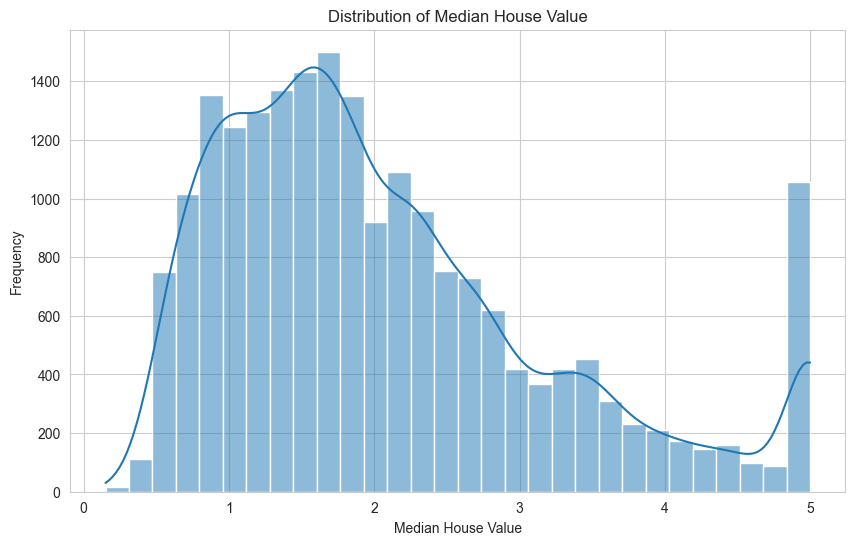

In [78]:
# Plot a histogram of the target variable (MedHouseVal)
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### Correlation Heatmap of all numeric features

Text(0.5, 1.0, 'Correlation Heatmap of California Housing Dataset')

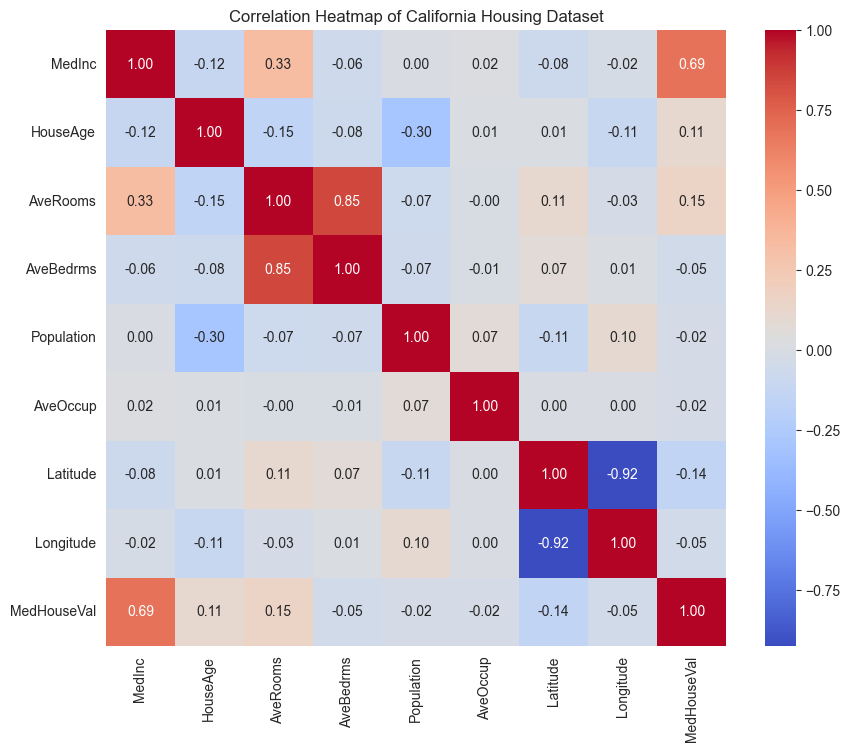

In [79]:
### Create a correlation heatmap of all numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of California Housing Dataset')  

In [80]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

#### Linear Relationship between MedInc and MedHouseVal

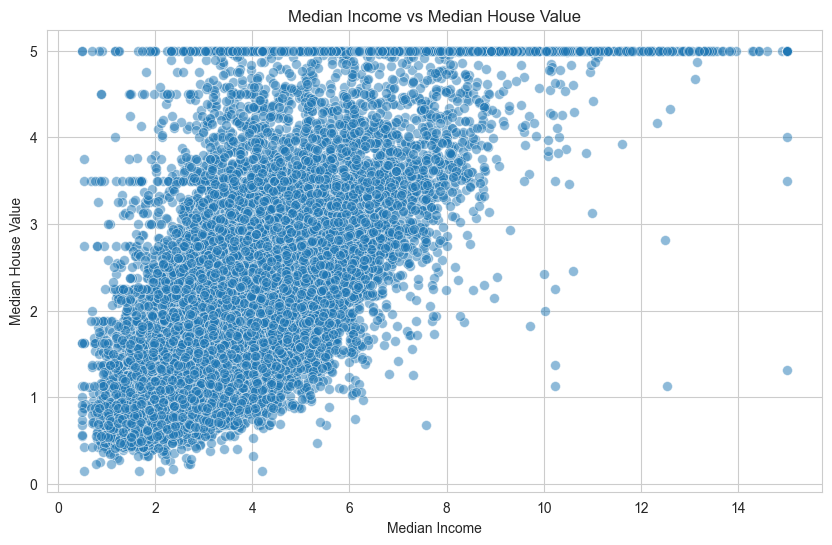

In [81]:
# Create a scatter plot of MedInc vs MedHouseVal
sns.scatterplot(
    x='MedInc',
    y='MedHouseVal',
    data=df,
    alpha=0.5,
    marker='o',
    palette='viridis',
    s=50  
)

plt.title('Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

### Relationship between Latitude and Longitude

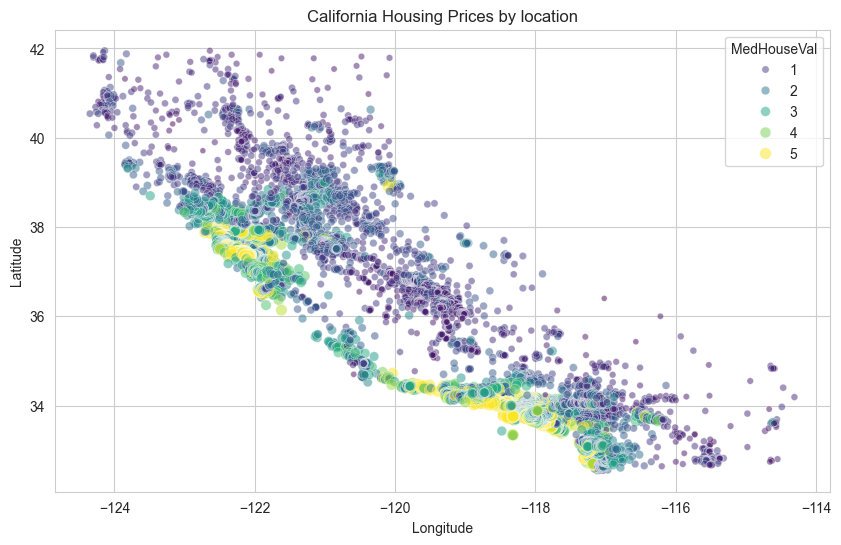

In [82]:
# Create a geographic scatter plot using Latitude and Longitude, coloured by MedHouseVal
sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='MedHouseVal',
    palette='viridis',
    size='MedHouseVal',
    s=10,
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by location')
plt.show()

### Interpretation of Plots

**1. Histogram of MedHouseVal**
- The distribution is positively skewed, indicating that majority of districts have relatively lower house values compared to the minority having much higher values.
- The majority of observations fall between $50,000 and $300,000, with the highest concentration around $150,000 to $180,000.
- There is a noticeable spike at the maximum value ($500,000), suggesting a possible upper cap or concentration of observations at that value.

**2. Correlation heatmap**
- The only significant correlations are: 
    - The median income and median house value have a medium income have a moderately strong strong positive correlation. An increase in one fairly leads to an increase in the other. 
    - The positive correlation between average number of bedrooms and average number rooms per household is is a very strong, suggesting a consistent simultaneous increase in both quantities.
- The rest of the features have very weak correlations.

**3. Scatter Plot of MedInc vs MedHouseVal**
- Although no line is explicitly drawn, the scatter plot shows a strong positive linear trend, as points form a diagonal pattern from lower-left to upper-right.
- At higher values, there is a flattened horizontal cluster of points due to value cap, creating a ceiling effect.

**4. Scatter plot of Latitude and Longitide**
- This plot shows thegeographical distribution of housing prices.
- The points form a spatial map, and the color intensity indicates significant variation by location.
- Higher prices are concentrated in specific regions, suggesting strong spatial dependence — location is important in the determination of  house value.

## Step A3: Data Preparation

### Data Splitting

In [83]:
# Split dataset into features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

feature_names = X.columns

# Split the dataset into train and test(80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

### Scaling

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step A4: Train Regression Models

### Linear Regression

In [85]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
y_pred_lr_model = lr_model.predict(X_test)

In [87]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=40)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",40
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [88]:
y_pred_rf_model = rf_model.predict(X_test)

In [89]:
print('Linear Regression Vs Random Forest Regressor:\n')
print(f'Linear Regression Score:{lr_model.score(X_test, y_test):.4f}')
print(f'Random Forest Regressor Score: {rf_model.score(X_test, y_test):.4f}')

Linear Regression Vs Random Forest Regressor:

Linear Regression Score:-4214.2918
Random Forest Regressor Score: 0.8051


## Step A5: Evaluate Regression Models

In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import numpy as np

def evaluate(model, X_test, name):
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    
    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R²:", r2)

# Evaluate models
evaluate(lr_model, X_test_scaled, "== Linear Regression ==\n")

evaluate(rf_model, X_test, "== Random Forest ==\n")


== Linear Regression ==

MAE: 0.5332001304956565
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R²: 0.5757877060324508

== Random Forest ==

MAE: 0.3288798209181202
MSE: 0.2553539782936927
RMSE: 0.505325616106776
R²: 0.8051341355761457


### Metrics Interpretation
**Linear Model**
- MAE — On average, the model's prediction is off by **0.53** units **($53,000)**.
- MSE — The model's average squared error is $0.55 \times (100,000)^2$, **5.5 billion dollars squared**
- RMSE — The typical prediction error is about **$74,000** with some large mistakes present.
- $R^2$ — Roughly **58%** of the variation in house prices is explained by the model indicating moderate predictive performance.

**Random Forest**
- MAE — Prediction is off by **0.33** units **($33,000)** on average.
- MSE — The model has an error variance of $0.25 \times (100,000)^2$, **3.5 billion dollars squared**
- RMSE — Typical errors are around **$50,000**.
- $R^2$ — The model's input features can explain about **81%** of the differences in house prices, while the remaining **19%** is due to factors not captured by the model or random variation. This indicates a very strong predictive performance.

## Step A6: Feature Importance

### Linear Regression feature importance

In [91]:
# In Linear Regression, feature importance = coefficients (weights)

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficients': lr_model.coef_
})

importance["abs_coef"] = importance["Coefficients"].abs()
importance = importance.sort_values(by="abs_coef", ascending=False)

print('== Feature Importance ==')
print()
importance

== Feature Importance ==



,Feature,Coefficients,abs_coef
6,Latitude,-0.896929,0.896929
7,Longitude,-0.869842,0.869842
0,MedInc,0.854383,0.854383
3,AveBedrms,0.339259,0.339259
2,AveRooms,-0.294410,0.294410
1,HouseAge,0.122546,0.122546
5,AveOccup,-0.040829,0.040829
4,Population,-0.002308,0.002308


### Random Forest feature importance

In [92]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('== Feature Importance ==:')
print()
feature_importance

== Feature Importance ==:



,Feature,Importance
0,MedInc,0.522645
5,AveOccup,0.137755
7,Longitude,0.093566
6,Latitude,0.093051
1,HouseAge,0.054527
2,AveRooms,0.038916
4,Population,0.030095
3,AveBedrms,0.029445


### Observations
- In the linear model, latitude, longitude and median income have high coefficients indicating that house pricing is heavily dependent on spatial distribution and median income.
- The Random Forest model, there is a siginificant dependence on median income alone. This non-linear effect suggests that median income is very useful in determining house pricing.

# PART B — Classification

## Background
The Iris dataset contains measuremnents of 150 iris flowers across three species. Your task is to build a multiclass classification model.

## Step B1: Load & Inspect the Dataset

In [93]:
# Import Packages
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [94]:
# Load the Iris dataset
iris = load_iris()

X = iris.data # Add the feature data to the DataFrame
y = iris.target # Add the target variable to the DataFrame

# Create a DataFrame from the Iris dataset
df = pd.DataFrame(X, columns=iris.feature_names)

# Add the target variable to the DataFrame
df['species'] = y
df['specie_names'] = df['species'].map(dict(enumerate(iris.target_names)))

## Step B2: Exploratory Data Analylsis (EDA)

In [95]:
# Display the first few rows of the DataFrame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,specie_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [96]:
# display the last few rows of the DataFrame
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,specie_names
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


In [97]:
# Shape of Dataset
df.shape

(150, 6)

In [98]:
# dataset structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   specie_names       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [99]:
# Statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
species,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [100]:
# NUmber of Species
df[['species', 'specie_names']].value_counts(ascending=False)

species  specie_names
0        setosa          50
1        versicolor      50
2        virginica       50
Name: count, dtype: int64

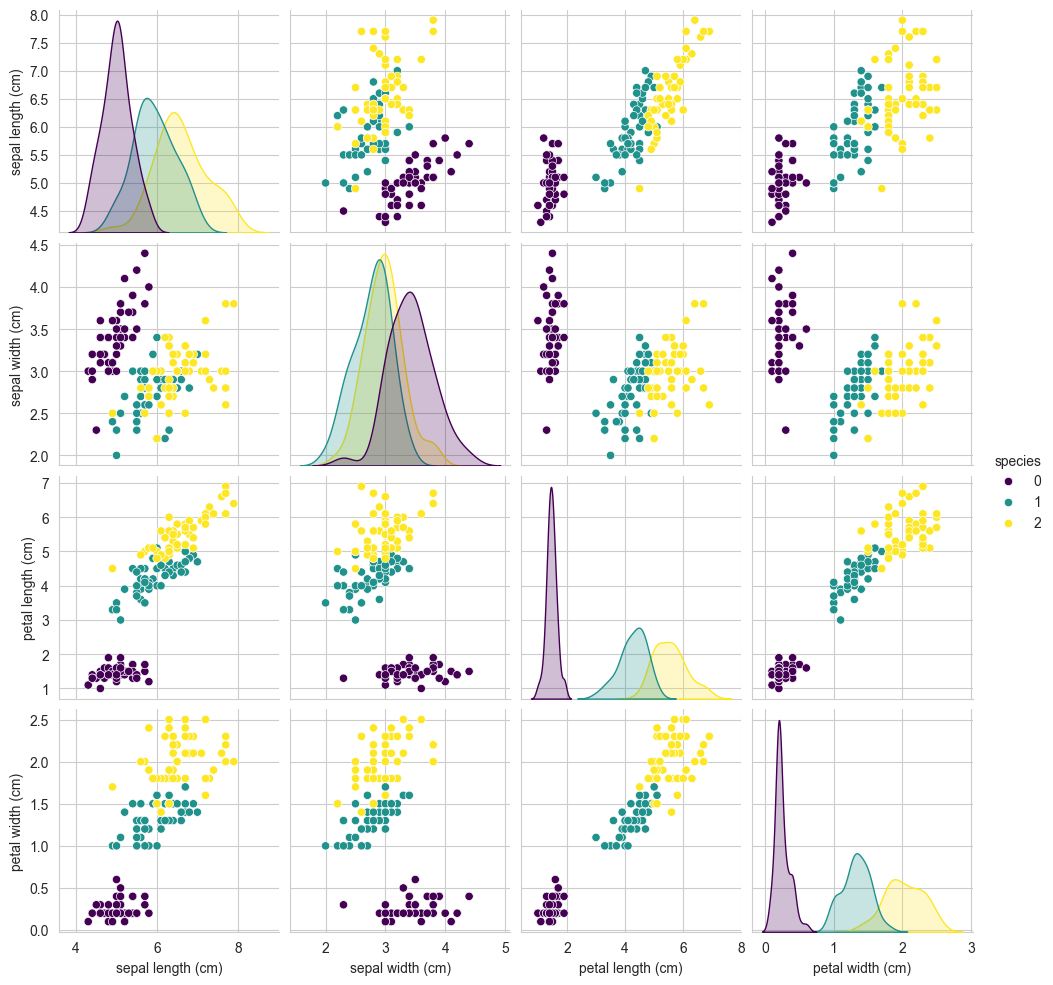

In [101]:
# Visualize the species clusters based on their features
sns.pairplot(df, hue='species', palette='viridis')
plt.show()

### Boxplots (feature distribution)

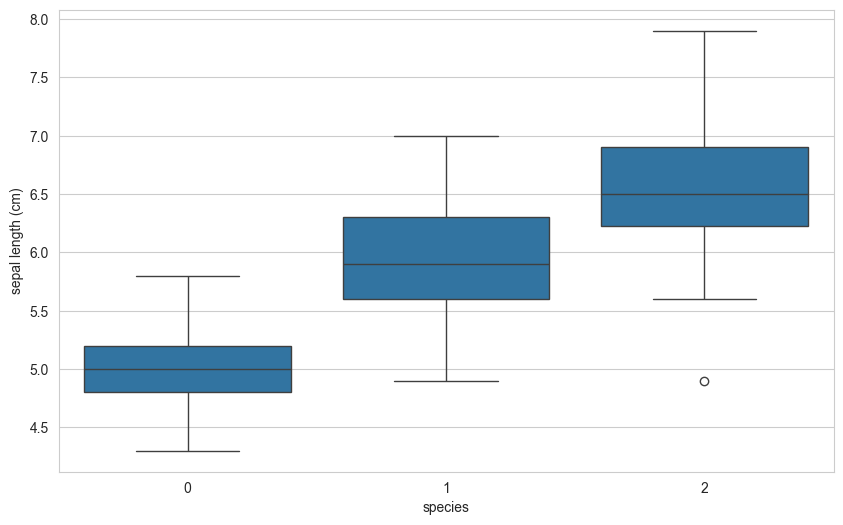

In [102]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='species', y='sepal length (cm)')
plt.show()

## Step B3: Data Preparation

### Data Splitting

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step B4: Train Classification Models

### Logistic Regression

In [105]:
from sklearn.linear_model import LogisticRegression

lr_model =  LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Decision Tree

In [106]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Random Forest

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step B5: Evaluate Classification Models

### Predictions

In [108]:
# Define the models
models = {
    "Logistic Regression": lr_model,
    "Decision TreeClassifier": tree_model,
    "Random Forest Classifier": rf_model
}

# Compute all metrics for each model
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1_Score': f1_score(y_test, y_pred, average='macro')
    })
df_results = pd.DataFrame(results).set_index('Model')
print('=== Classification Metrics — All Models (Multiclass: Iris Flower) ===')
print()
df_results.round(4)

=== Classification Metrics — All Models (Multiclass: Iris Flower) ===



,Accuracy,Precision,Recall,F1_Score
Model,,,,
Logistic Regression,1.0,1.0,1.0,1.0
Decision TreeClassifier,1.0,1.0,1.0,1.0
Random Forest Classifier,1.0,1.0,1.0,1.0


In [109]:
print(df_results.round(4).to_string())

                          Accuracy  Precision  Recall  F1_Score
Model                                                          
Logistic Regression            1.0        1.0     1.0       1.0
Decision TreeClassifier        1.0        1.0     1.0       1.0
Random Forest Classifier       1.0        1.0     1.0       1.0


### Confusion Matrix (Best Model)

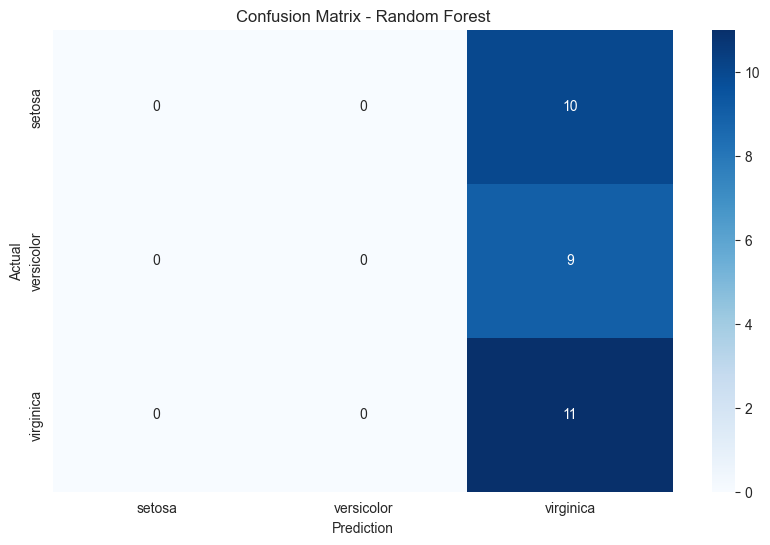

In [110]:
best_model = rf_model

y_pred = best_model.predict(X_test)

cm  = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

## Step B6: Decision Boundary Visualisation

### Reduce to 2 features

In [111]:
# Plot how the best model separates classes in 2D feature space
# We reduce to 2 feature for visualisation

X_2d = df[['petal length (cm)', 'petal width (cm)']]
y_2d = df['species']

X_train, X_test, y_train, y_test = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

### Train model

In [112]:
rf_2d = RandomForestClassifier(random_state=42)
rf_2d.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Plot decision boundary

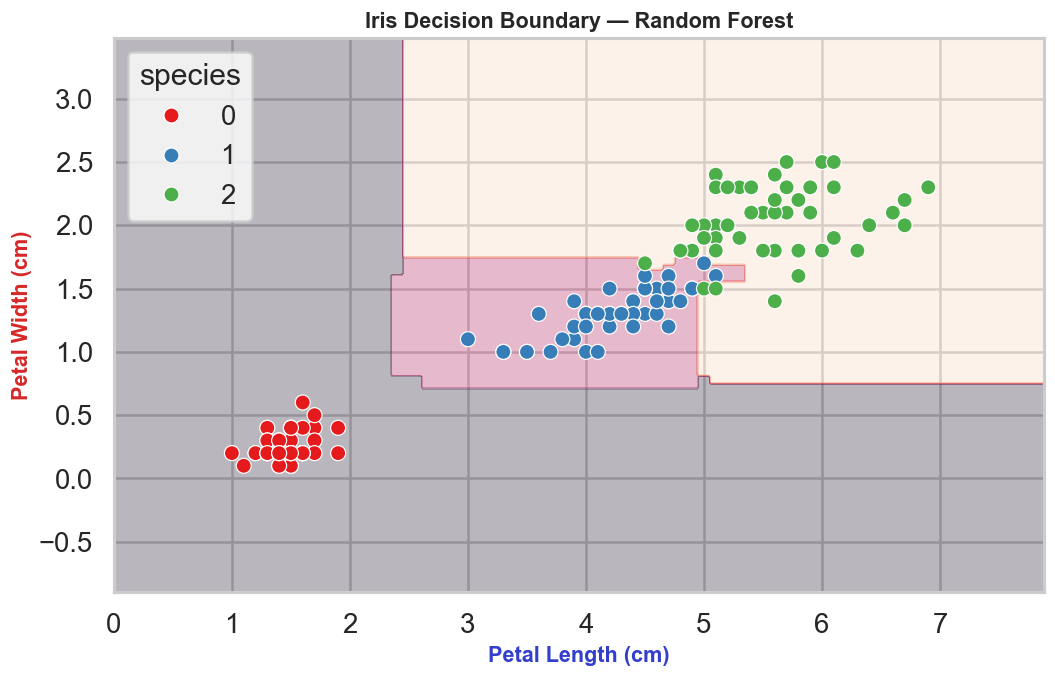

In [113]:
# Create grid decision boundary (Grid)
x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over grid
Z = rf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Style settings
sns.set_theme(
    style="whitegrid",
    palette="deep",
    context="talk"
)

# Plot
plt.figure(figsize=(10, 6), dpi=120)

plt.contourf(xx, yy, Z, alpha=0.3)

sns.scatterplot(
    x=X_2d.iloc[:,0],
    y=X_2d.iloc[:,1],
    hue=y_2d,
    palette='Set1'
)
plt.xlabel("Petal Length (cm)", fontsize=13, fontweight="bold", color="#333fcc")
plt.ylabel("Petal Width (cm)", fontsize=13, fontweight="bold", color="#d62728")
plt.title("Iris Decision Boundary — Random Forest", fontsize=13, fontweight="bold")
plt.show()

# Part C — Conceptual Quiz
---

## Section 1 — Regression (Questions 1-6)
These questions relate to Part A of the assignment — predicting California house prices.

| Questions | Q1 | Q2 | Q3 | Q4 | Q5 | Q6 |
|-----------|----|----|----|----|----|----|
| Answers   | C  | B  | B  | C  | B  | C  |

## Section 2 — Classification (Questions 7-12)
These questions relate to Part B of the assignment — predicting Iris flower species.

| Questions     |  Q7  |  Q8  |  Q9  |  Q10  |  Q11  |  Q12  |
|---------------|------|------|------|-------|-------|-------|
| **Answers**   |  B   |  B   |  C   |   B   |   C   |   C   |

## Section 3 — Classification (Questions 13-15)

##### Q13. Differences Between Regression and Classification

- Regression, is a supervised learning algorithm or predictive modelling technique used in analyzing the relationship between a dependent variable (`target`) and one or more independent variables (`features`). It involves the prediction of of a number of infinitely many possible outputs.
- **Example**: Real Estate — Prediction of house of prices (target) based on some features such as square feet, number of rooms, median income, median house value etc.
- It must be noted that we are talking about linear regression and not logistic regression which is a type of classification model.

- Classification on the other hand, which is also a supervised learning algorithm involves prediction of `classes` or `categories`. It learns from examples showing specific classes or categories of outcomes based on a particular feature, learns from the models and then tries to predict which class/category a given feature falls into.
- The classes could be either binary (0 & 1) or multi-class (more than 2 classes)

- **Example**: HealthCare — Breast cancer prediction. In the diagnosis of breast cancer, doctors try to determine if a lump or tumour is either `malignant` (cancerous/dangerous)  or `benign` (neither cancerous nor dangerous)

- The major difference between the two models is that, linear regression predicts continuous numerical values while classification predicts discrete classes or categories.

#### Q14. Interpretation for an RMSE of 0.72 where house prices are in units of $100,000 & Concrete Steps for Improvement.
- The RMSE of 0.72 means that the typical error in the regression model's prediction is about $72,000. This means that on average, the model's prediction is off by $72,000. So, for a house predicted at $300,000, the prediction would be off by $72,000 making the actual value to be typically around $228,000.

However, improvements can be made by taking the following steps:
- Reducing errors by cleaning and making sure the model learns from reliable, consistent data.
- Giving the model better context so as to increase its accuracy in understanding of business behavior.
- Trying better models like Random Forest and XGBoost to capture some non-linear relationships and complex patterns.
- Handling outliers (which affects RMSE) more carefully and fine-tunning the model so as to reduce prediction errors, and ensuring optimal performance.

#### Q15. Confusion Matrix
- From the results of my confusion matrix the two Iris species with the most consfusion were the species
